<table width=100%>
    <tr>
        <td width = 40% align = "left">
            <h3> MTH786 Machine Learning with Python</h3>
        </td>
        <td width = 35%>            
        </td>
        <td width = 25% align = "left">
            <h3>Semester A </h3>
        </td>
    </tr>
    <tr>
        <td width = 40% align = "left">
            <h3> Lab Coursework 4</h3>
        </td>
        <td width = 35%>            
        </td>
        <td width = 25% align = "left">
            <h3>Dr Nicola Perra </h3>
        </td>
    </tr>
</table>

We start by loading necessary libraries, including NumPy (used for linear algebra calculations) and MatPlotLib (used for visualisation).

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

### Linear regression
By completing this exercise you will write a set of functions that are used for building a linear regression for a given data samples. You will then finish by calculating a linear regression for a height-weight dataset. 


1. Implement function **linear_regression_data** that computes (and outputs) the linear regression data matrix defined as
$$
\mathbf{X} = 
\begin{pmatrix}
1 & x^{(1)}_1 & x^{(1)}_2 & \ldots & x^{(1)}_d \\
1 & x^{(2)}_1 & x^{(2)}_2 & \ldots & x^{(2)}_d \\
\vdots & \vdots & \vdots & \ddots & \vdots & \\
1 & x^{(s)}_1 & x^{(s)}_2 & \ldots & x^{(s)}_d \\
\end{pmatrix}
$$
The function **linear_regression_data**  should take the NumPy array *data_inputs* as argument. Here, *data_inputs* is supposed to be a data matrix containing all inputs in the matrix form as follows
$$
data\_inputs = 
\begin{pmatrix}
x^{(1)}_1 & x^{(1)}_2 & \ldots & x^{(1)}_d \\
x^{(2)}_1 & x^{(2)}_2 & \ldots & x^{(2)}_d \\
\vdots & \vdots & \ddots & \vdots & \\
x^{(s)}_1 & x^{(s)}_2 & \ldots & x^{(s)}_d \\
\end{pmatrix}.
$$
The function should output data matrix $\mathbf{X}$.

In [46]:
def linear_regression_data(data_inputs):
    s = data_inputs.shape[0]
    x0 = np.ones(s)
    data_matrix = np.column_stack((x0, data_inputs))
    return data_matrix

Test your function with the following unit tests

In [34]:
from numpy.testing import assert_array_almost_equal, assert_array_equal

test_inputs = np.array([[1], [2], [3], [4]])
assert_array_equal(
    linear_regression_data(test_inputs), np.array([[1, 1], [1, 2], [1, 3], [1, 4]])
)

In [35]:
test_inputs = np.array([[1, 2], [2, 3], [3, 4], [4, 5]])
assert_array_equal(
    linear_regression_data(test_inputs),
    np.array([[1, 1, 2], [1, 2, 3], [1, 3, 4], [1, 4, 5]]),
)

Try your function with this random samples

In [36]:
samples, dimensions = np.random.randint(low=2, high=100, size=2)
test_inputs = np.random.rand(samples, dimensions)

print(samples, dimensions)
print(test_inputs)
# write your code here

39 32
[[0.17361644 0.10917448 0.94550637 ... 0.25478169 0.32013462 0.31739713]
 [0.7191517  0.23449615 0.38789821 ... 0.45149632 0.88322394 0.6734539 ]
 [0.85387888 0.12156805 0.81856689 ... 0.96447987 0.49752428 0.24715992]
 ...
 [0.9778981  0.7555142  0.44047931 ... 0.29849183 0.36760006 0.29687384]
 [0.79439061 0.97979275 0.5692263  ... 0.82564585 0.4708261  0.93346508]
 [0.81722108 0.25725844 0.57772001 ... 0.43032644 0.8958836  0.58763145]]


2. Write a function **linear_regression** that takes two arguments *data_matrix* and *data_outputs*, which computes and returns the solution $\hat{\mathbf{W}}$ of the normal equation
$$
\mathbf{X}^{\top}\mathbf{X} \hat{\mathbf{W}} = \mathbf{X}^{\top}\mathbf{Y}
$$
Here $\mathbf{X}$  is the mathematical representation of *data_matrix*
and $\mathbf{Y}$ is the mathematical representation of *data_outputs*, while $\hat{\mathbf{W}}$ is a mathematical representation for weights/coefficients of the linear regression.

**Hint**: you the function np.linalg.solve
https://numpy.org/doc/stable/reference/generated/numpy.linalg.solve.html

In [ ]:
def linear_regression(data_matrix, data_outputs):
    X, Y = data_matrix, data_outputs
    XTX, XTY = np.matmul(X.T, X), np.matmul(X.T, Y)
    W = np.linalg.solve(
        XTX, XTY
    )  # the equivalent of np.matmul(np.linalg.inv(XTX), XTY), the exact solution.
    return W

Test your function with the following unit tests

In [38]:
test_data_matrix = np.array([[1, 0.5], [1, 1.5]])
test_outputs = np.array([[1], [1]])
assert_array_almost_equal(
    linear_regression(test_data_matrix, test_outputs), np.array([[1], [0]])
)

In [39]:
test_data_matrix = np.array([[1, 0.98], [1, 1.02]])
test_outputs = np.array([[-0.1], [0.3]])
assert_array_almost_equal(
    linear_regression(test_data_matrix, test_outputs), np.array([[-9.9], [10]])
)

Try your code with this random data

In [40]:
samples, dimensions, output_dimensions = np.random.randint(low=2, high=100, size=3)
test_inputs = np.random.rand(samples, dimensions)
test_outputs = np.random.rand(samples, output_dimensions)

print(samples, dimensions, output_dimensions)
print(test_inputs)
print("--")
print(test_outputs)

65 21 5
[[0.38009083 0.5133343  0.11392403 ... 0.59594896 0.91070096 0.13208183]
 [0.21193033 0.64814506 0.76131258 ... 0.40409386 0.0800015  0.03747038]
 [0.81874986 0.8953416  0.97405437 ... 0.96999983 0.88641319 0.41475254]
 ...
 [0.58705832 0.82677637 0.55504853 ... 0.24267832 0.86379582 0.16722855]
 [0.40163216 0.87512728 0.53827497 ... 0.93443137 0.78982854 0.39337478]
 [0.49137485 0.74234759 0.49532015 ... 0.65280998 0.19440781 0.27665472]]
--
[[0.41125809 0.73083582 0.19599736 0.4492082  0.88236839]
 [0.58679706 0.64671072 0.18298207 0.93972998 0.60359418]
 [0.42548904 0.84100036 0.82598112 0.06327312 0.14624305]
 [0.57182524 0.80043263 0.75275682 0.76052042 0.33193252]
 [0.75873907 0.40330597 0.77560222 0.54887027 0.09075093]
 [0.84971279 0.39309163 0.69700894 0.81494035 0.74211361]
 [0.44148348 0.32062354 0.71857017 0.92720919 0.97402257]
 [0.02736406 0.41865031 0.31020342 0.87686937 0.63122829]
 [0.12244534 0.25618055 0.71632307 0.4297512  0.9370164 ]
 [0.83778486 0.17694322

3. Write a function **prediction_error** that evaluates a mean-squared error over the set of data inputs and outputs. The function **prediction_error** takes the arguments _data_matrix_, _data_ouputs_ and _weights_ as inputs and returns a mean squared error defined by
$$
\mathrm{MSE} = \frac{1}{2s} \left\|\mathbf{X}\mathbf{W} - \mathbf{Y} \right\|^2,
$$
where $\mathbf{X}$ is a mathematical representation of _data_matrix_, $\mathbf{Y}$ is a mathematical representation of _data_outputs_ and $\mathbf{W}$ is a mathematical representation of _weights_.

In [41]:
def prediction_error(data_matrix, data_outputs, weights):
    X, Y, W = data_matrix, data_outputs, weights
    s = X.shape[0]
    MSE = 1 / (2 * s) * np.linalg.norm(np.matmul(X, W) - Y) ** 2
    return MSE

Test your function with the following unit tests

In [42]:
test_data_matrix = np.array([[1, 0.98], [1, 1.02]])
test_data_outputs = np.array([[-0.1], [0.3]])
test_weights = np.array([[-9.9], [10]])
assert_array_almost_equal(
    prediction_error(test_data_matrix, test_data_outputs, test_weights), 0
)

In [43]:
test_data_matrix = np.array([[1, 1, -1], [1, 2, 2]])
test_data_outputs = np.array([[-1, 2], [1, 3]])
test_weights = np.array([[0, 0], [1, 2], [3, 4]])
assert_array_almost_equal(
    prediction_error(test_data_matrix, test_data_outputs, test_weights), 36.75
)

4. In the next two parts we apply the above to height-weight-gender data, considered in the lectures. Our goal is to build a linear regression for a weight as a function of height or height and gender. We start by reading the data from attached .csv file.   **Important:** please check that the file *height_weight_genders.csv* is located in the same folder with your Jupyter notebook.

In [44]:
converter_function = lambda x: 0 if "Male" in x else 1
genders = np.genfromtxt(
    "height_weight_genders.csv",
    delimiter=",",
    skip_header=1,
    usecols=[0],
    converters={0: converter_function},
)
heights = np.genfromtxt(
    "height_weight_genders.csv", delimiter=",", skip_header=1, usecols=[1]
)
weights = np.genfromtxt(
    "height_weight_genders.csv", delimiter=",", skip_header=1, usecols=[2]
)

print(genders)
print(heights)
print(weights)

[0 0 0 ... 1 1 1]
[73.84701702 68.78190405 74.11010539 ... 63.86799221 69.03424313
 61.94424588]
[241.89356318 162.31047252 212.74085556 ... 128.47531878 163.85246135
 113.64910268]


Let us first build a scatter plot of weight-height data (excluding gender).

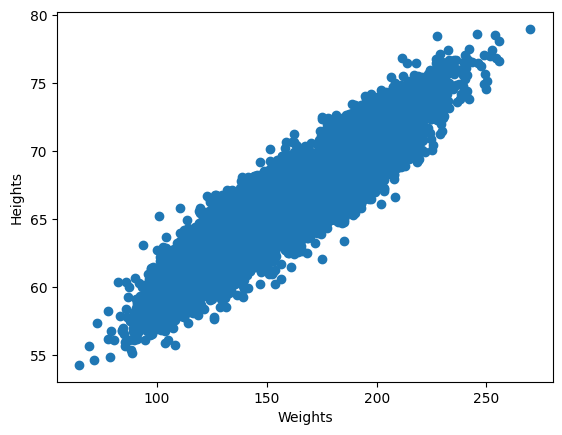

In [45]:
plt.scatter(weights, heights)
plt.xlabel("Weights")
plt.ylabel("Heights")
plt.show()

In the next cell you use the functions defined above to find optimal regression weights. You then asked to evaluate your training error and plot a linear regression together with the scatter plot above.

In [20]:
data_matrix = linear_regression_data(heights)
regression_weights = linear_regression(data_matrix, weights)

Test your results with the following unit tests

In [ ]:
assert_array_almost_equal(regression_weights, np.array([-350.737192, 7.717288]))

Print the prediction error below

In [29]:
MSE = prediction_error(
    data_matrix=data_matrix, data_outputs=weights, weights=regression_weights
)
print(MSE)

74.6467419745648


Add a plot of linear regression (in red color) to the above scatter plot.

[]

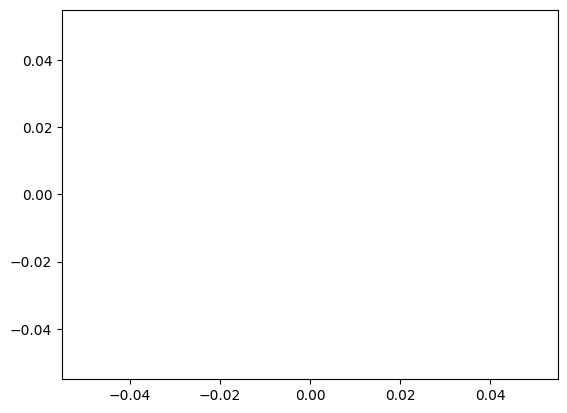

In [30]:
plt.plot()

6. In this part we include gender parameter to our linear regression. This means that now you are predicting a weight of the person by using his/her height and gender data. As before we start with the scatter plot, which is now a 3D one.

In [ ]:
# YOUR CODE HERE

In the next cell you use the functions defined above to find optimal regression weights. You then asked to evaluate your training error and plot a linear regression together with the scatter plot above.

In [2]:
# YOUR CODE HERE

Test your function with the following unit tests

In [ ]:
assert_array_almost_equal(
    regression_weights, np.array([-225.545792, 5.976941, -19.377711])
)

What is the prediction error?

In [3]:
# WRITE YOUR CODE HERE